In [13]:
# !pip install sqlalchemy psycopg2-binary pandas matplotlib seaborn

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os

os.makedirs("Charts", exist_ok=True)

# --- Database credentials ---
DB_USER = "postgres"
DB_PASSWORD = "aws123"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "Adventureworks"

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

# Quick connection test
test = pd.read_sql("SELECT count(*) AS view_count FROM information_schema.views WHERE table_schema IN ('analytics','kpi');", engine)
print(test)

   view_count
0          32


In [15]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


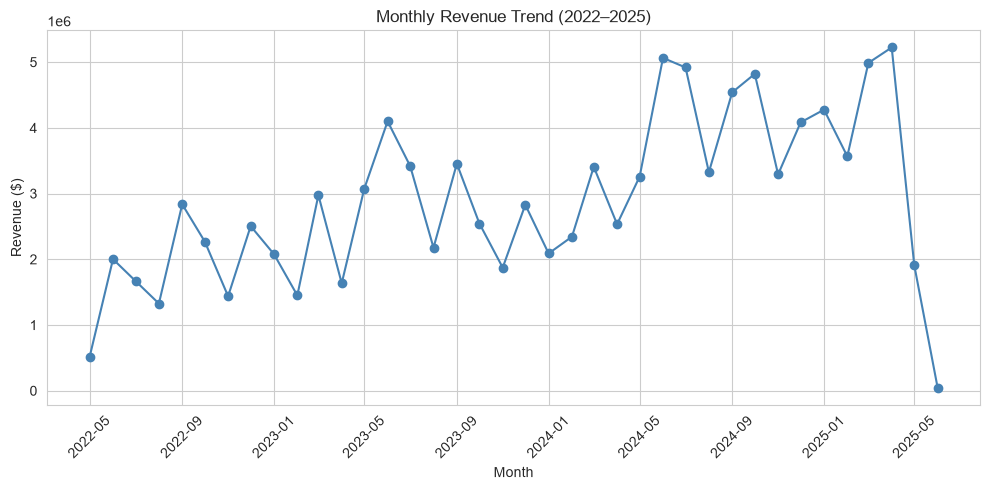

In [16]:
df_revenue = pd.read_sql("SELECT * FROM kpi.sales_growth_summary ORDER BY order_month;", engine)

plt.figure()
plt.plot(df_revenue["order_month"], df_revenue["total_revenue"], marker="o", color="steelblue")
plt.title("Monthly Revenue Trend (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Charts/monthly_revenue_trend.png", dpi=300, bbox_inches="tight")
plt.show()

## Business insight:
Revenue grew steadily from 2022 through early 2025, but the last data point (June 2025) shows a sharp drop — this is a partial month in the dataset (data ends June 29, 2025), not a real business decline. Any month-over-month or year-over-year figure involving 2025 should be read with this in mind.

C:\Users\Haroon\AppData\Local\Temp\ipykernel_30772\3994359423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_territory, x="total_revenue", y="territory", palette="viridis")


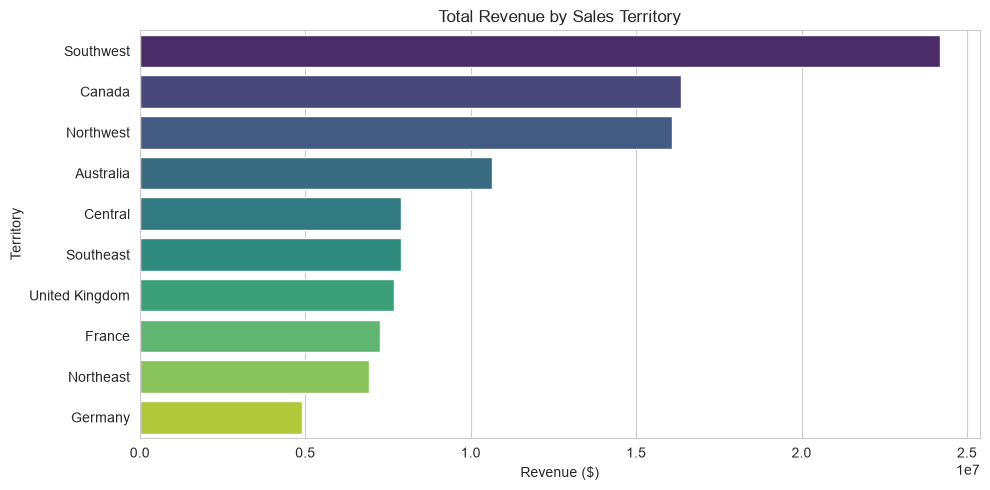

In [17]:
df_territory = pd.read_sql("SELECT * FROM kpi.regional_revenue ORDER BY total_revenue DESC;", engine)

plt.figure()
sns.barplot(data=df_territory, x="total_revenue", y="territory", palette="viridis")
plt.title("Total Revenue by Sales Territory")
plt.xlabel("Revenue ($)")
plt.ylabel("Territory")
plt.tight_layout()
plt.savefig("Charts/total_revenue_salesTerritory.png", dpi=300, bbox_inches="tight")
plt.show()

## Insight:
Southwest, Canada, and Northwest are the top 3 territories by revenue, together contributing a majority of total sales. Germany, Northeast, and France are the lowest performers — worth investigating whether this reflects market saturation, sales headcount, or genuine lower regional demand.

C:\Users\Haroon\AppData\Local\Temp\ipykernel_30772\174062776.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_segments, x="customer_segment", y="num_customers",


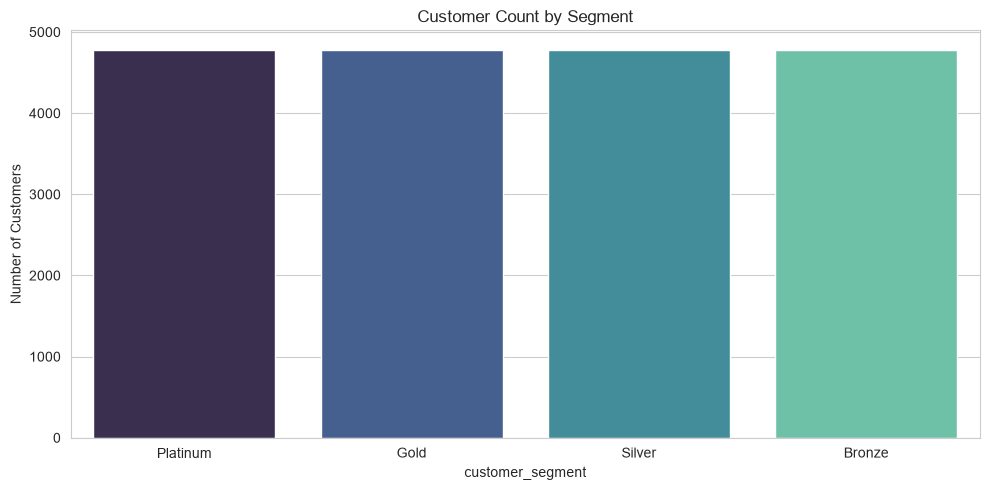

In [18]:
df_segments = pd.read_sql("""
    SELECT customer_segment, COUNT(*) AS num_customers, ROUND(AVG(total_revenue),2) AS avg_revenue
    FROM analytics.customer_segments
    GROUP BY customer_segment
    ORDER BY avg_revenue DESC;
""", engine)

fig, ax1 = plt.subplots()
sns.barplot(data=df_segments, x="customer_segment", y="num_customers",
            order=["Platinum","Gold","Silver","Bronze"], palette="mako", ax=ax1)
ax1.set_title("Customer Count by Segment")
ax1.set_ylabel("Number of Customers")
plt.tight_layout()
plt.savefig("Charts/customer_count_by_segment.png", dpi=300, bbox_inches="tight")
plt.show()

## Insight:
Segments are evenly sized by design (~4,780 customers each, via quartile-based scoring) but revenue is not — Platinum customers average $18.5K in lifetime spend vs. $136 for Bronze. This confirms a small, high-value customer base drives disproportionate revenue.

C:\Users\Haroon\AppData\Local\Temp\ipykernel_30772\1582151821.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_products, x="total_qty_sold", y="product_name", palette="crest")


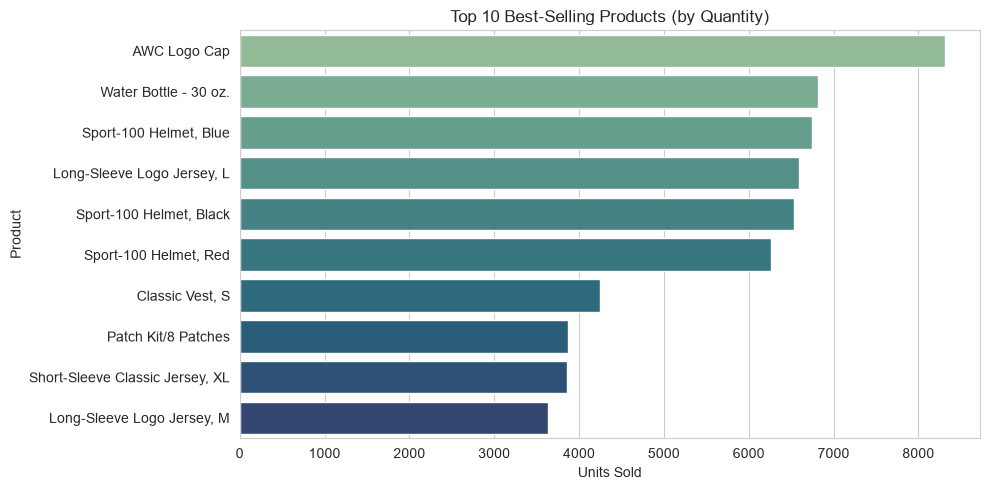

In [19]:
df_products = pd.read_sql("SELECT * FROM kpi.best_selling_products ORDER BY total_qty_sold DESC LIMIT 10;", engine)

plt.figure()
sns.barplot(data=df_products, x="total_qty_sold", y="product_name", palette="crest")
plt.title("Top 10 Best-Selling Products (by Quantity)")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("Charts/top_10_best_selling_products.png", dpi=300, bbox_inches="tight")
plt.show()

## Insight:
Low-cost accessories (caps, water bottles, helmets) dominate by unit volume, but as Chart 5 shows, they're not where the big dollars are — a useful distinction between "popular" and "profitable."

C:\Users\Haroon\AppData\Local\Temp\ipykernel_30772\1496320505.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_category, x="category", y="total_revenue", palette="Blues_d", ax=ax1)
C:\Users\Haroon\AppData\Local\Temp\ipykernel_30772\1496320505.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_category, x="category", y="category_margin_pct", palette="Oranges_d", ax=ax2)


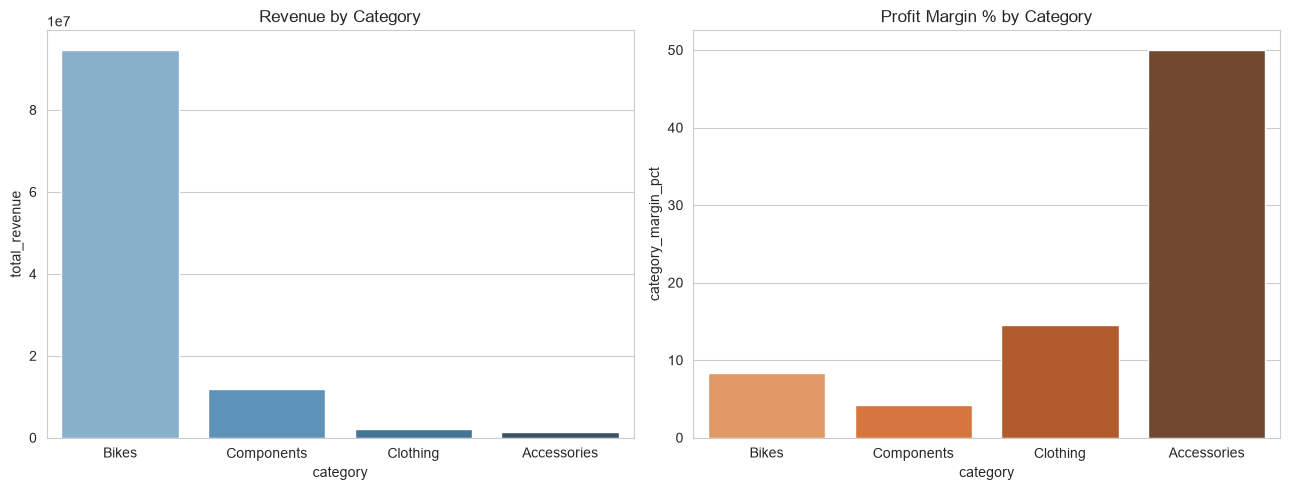

In [20]:
df_category = pd.read_sql("SELECT * FROM kpi.category_performance ORDER BY total_revenue DESC;", engine)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))
sns.barplot(data=df_category, x="category", y="total_revenue", palette="Blues_d", ax=ax1)
ax1.set_title("Revenue by Category")
sns.barplot(data=df_category, x="category", y="category_margin_pct", palette="Oranges_d", ax=ax2)
ax2.set_title("Profit Margin % by Category")
plt.tight_layout()
plt.savefig("Charts/category_performance.png", dpi=300, bbox_inches="tight")
plt.show()

## Insight:
Bikes generate 86% of total revenue but only an 8.4% margin. Accessories are just 1.2% of revenue but carry a 50% margin. This is the single clearest opportunity in the whole dataset: pushing accessory attach-rate at point of sale would improve overall profitability without needing new bike sales at all.

C:\Users\Haroon\AppData\Local\Temp\ipykernel_30772\1323223988.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_employees, x="total_revenue", y="employee_name", palette="rocket")


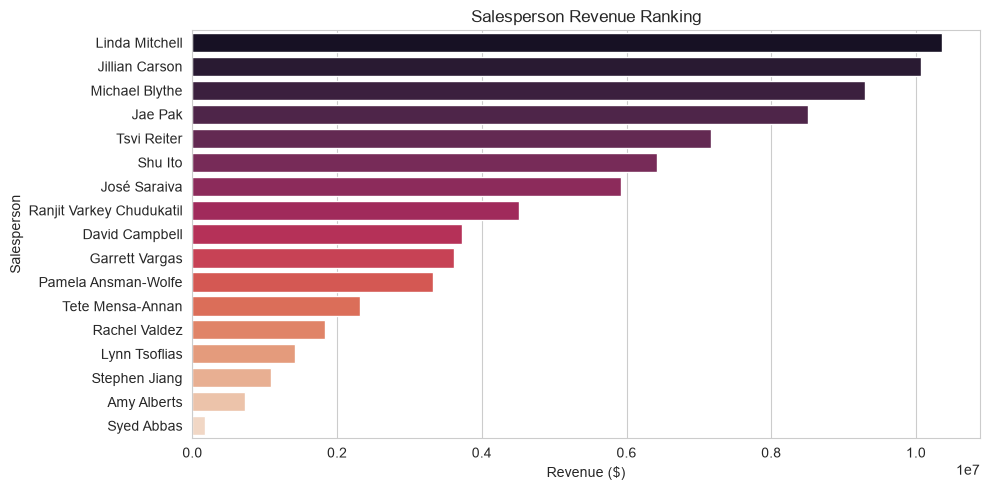

In [21]:
df_employees = pd.read_sql("SELECT * FROM analytics.employee_analytics WHERE total_revenue IS NOT NULL ORDER BY total_revenue DESC;", engine)

plt.figure()
sns.barplot(data=df_employees, x="total_revenue", y="employee_name", palette="rocket")
plt.title("Salesperson Revenue Ranking")
plt.xlabel("Revenue ($)")
plt.ylabel("Salesperson")
plt.tight_layout()
plt.savefig("Charts/salesperson_revenue_ranking.png", dpi=300, bbox_inches="tight")
plt.show()

## Insight:
Linda Mitchell and Jillian Carson lead the team, each generating over $10M in lifetime sales. Note: the pct_of_quota_achieved figures in employee_analytics look inflated (often 1000%+) because salesquota is a per-period target while revenue here is all-time — don't present that column as-is without this caveat.

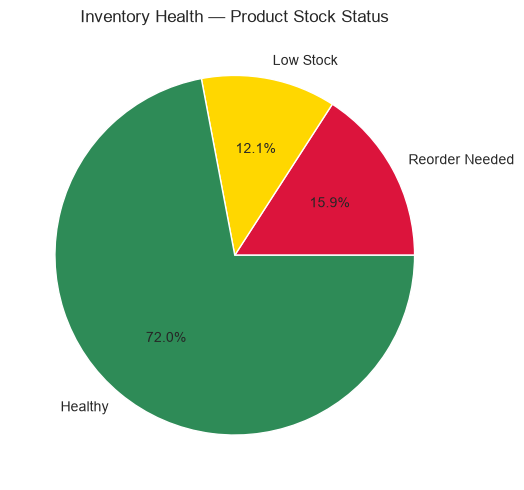

In [22]:
df_inventory = pd.read_sql("SELECT * FROM kpi.inventory_health;", engine)

plt.figure()
colors = {"Healthy":"seagreen", "Low Stock":"gold", "Reorder Needed":"crimson"}
plt.pie(df_inventory["num_products"], labels=df_inventory["stock_status"],
        autopct="%1.1f%%", colors=[colors[s] for s in df_inventory["stock_status"]])
plt.title("Inventory Health — Product Stock Status")
plt.tight_layout()
plt.savefig("Charts/inventory_health_stock_status.png", dpi=300, bbox_inches="tight")
plt.show()

## Insight:
72% of products are at healthy stock levels, but 16% need immediate reordering and another 12% are running low — nearly 1 in 3 products needs supply-chain attention soon.

In [23]:
total_revenue = pd.read_sql("SELECT SUM(subtotal) AS v FROM analytics.sales_order_fact;", engine)["v"][0]
total_customers = pd.read_sql("SELECT COUNT(*) AS v FROM analytics.customer_analytics;", engine)["v"][0]
repeat_pct = pd.read_sql("SELECT pct_of_customers FROM kpi.repeat_customers WHERE customer_type_flag='Repeat Customer';", engine)["pct_of_customers"][0]
top_territory = pd.read_sql("SELECT territory FROM kpi.top_territories LIMIT 1;", engine)["territory"][0]
top_category = pd.read_sql("SELECT category FROM kpi.category_performance ORDER BY total_revenue DESC LIMIT 1;", engine)["category"][0]

summary = pd.DataFrame({
    "KPI": ["Total Revenue", "Total Customers", "% Repeat Customers", "Top Territory", "Top Category"],
    "Value": [f"${total_revenue:,.0f}", f"{total_customers:,}", f"{repeat_pct}%", top_territory, top_category]
})
summary

,KPI,Value
0,Total Revenue,"$109,846,381"
1,Total Customers,"19,119"
2,% Repeat Customers,39.07%
3,Top Territory,Southwest
4,Top Category,Bikes


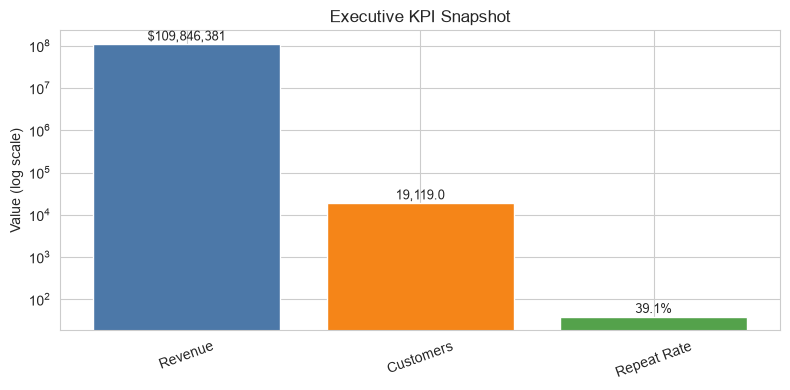

In [26]:
summary_chart = pd.DataFrame({
    "KPI": ["Revenue", "Customers", "Repeat Rate"],
    "Value": [total_revenue, total_customers, repeat_pct]
})

plt.figure(figsize=(8, 4))
bar_colors = ["#4C78A8", "#F58518", "#54A24B"]
plt.bar(summary_chart["KPI"], summary_chart["Value"], color=bar_colors)
plt.yscale("log")
plt.title("Executive KPI Snapshot")
plt.ylabel("Value (log scale)")
plt.xticks(rotation=20)

for i, v in enumerate(summary_chart["Value"]):
    label = f"${v:,.0f}" if i == 0 else f"{v:,}" if i == 1 else f"{v:.1f}%"
    plt.text(i, v * 1.05, label, ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("Charts/executive_kpi_snapshot.png", dpi=300, bbox_inches="tight")
plt.show()

## Insight:
A one-glance executive scorecard: ~$110M lifetime revenue across ~19,100 customers, only 39% of whom are repeat buyers — reinforcing that customer retention (Chart 3 / this KPI) is a bigger lever than customer acquisition at this stage.

C:\Users\Haroon\AppData\Local\Temp\ipykernel_30772\2901505671.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_suppliers, x="supplier_rating", y="num_vendors", order=["Reliable","Acceptable","At Risk"], palette="flare")


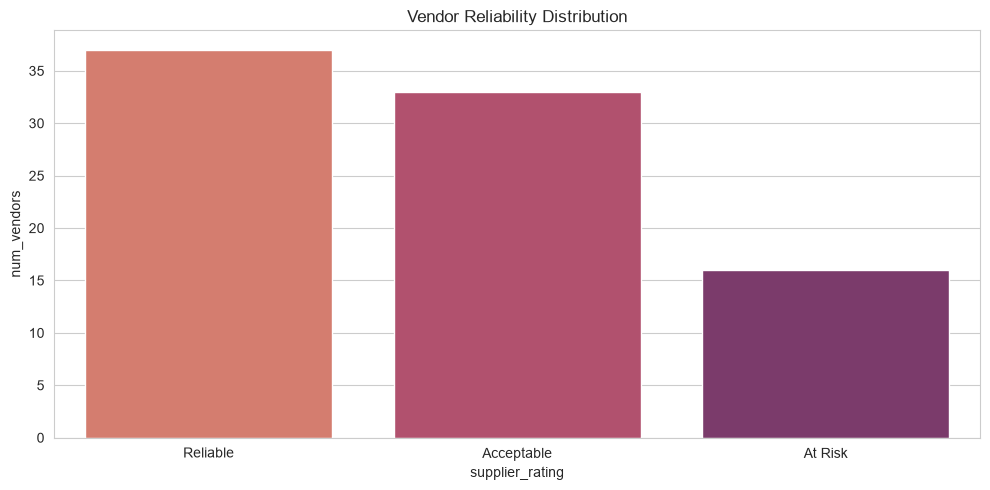

In [24]:
df_suppliers = pd.read_sql("SELECT supplier_rating, COUNT(*) AS num_vendors FROM kpi.supplier_performance GROUP BY supplier_rating;", engine)

plt.figure()
sns.barplot(data=df_suppliers, x="supplier_rating", y="num_vendors", order=["Reliable","Acceptable","At Risk"], palette="flare")
plt.title("Vendor Reliability Distribution")
plt.tight_layout()
plt.savefig("Charts/vendor_reliability_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Insight:
16 of 86 active vendors are flagged "At Risk" (high reject rates or long lead times) — worth a supplier review, especially if any of them supply high-volume categories like Bikes.

### 5 Business Risks
1. 16 of 86 active vendors (18.6%) are flagged "At Risk" for high reject rates or long lead times, including Superior Bicycles — your single largest vendor by spend ($4.56M) — which has a 5.2% reject rate. A supply disruption here would hit a high-revenue category hard. (Source: kpi.supplier_performance)
2. 95 products (18.9% of the catalog) need reordering or are running low on stock (80 "Reorder Needed" + 61 "Low Stock" out of 504 total). Given Bikes drive 86% of revenue, any stockouts in that category compound quickly. (Source: kpi.inventory_health)
3. Customer retention rates are low and trending toward single digits to ~27% year-over-year, though this is partly explained by rapid new-customer growth diluting the ratio — it's still worth monitoring whether genuine churn is also rising underneath that growth. (Source: kpi.customer_retention)
4. 60.9% of customers are one-time buyers, contributing only ~6% of total revenue collectively. If the online acquisition channel's cost-per-customer isn't well below their contribution, this could be a quietly unprofitable growth channel. (Source: kpi.repeat_customers)
5. Heavy revenue concentration in a single category: Bikes alone represent 86.2% of total revenue. Any category-specific shock (input cost spike, competitor pricing pressure, safety recall) would disproportionately impact the whole business. (Source: kpi.category_performance)

### 5 Actionable Recommendations
1. Launch an accessory bundling initiative at the point of sale for bike purchases, using the 50%-margin Accessories category to lift blended profitability — target a specific attach-rate KPI (e.g., "X% of bike orders include an accessory") and track it monthly via kpi.category_performance.
2. Build a retention program specifically for customers who've placed 2–3 orders, since the data shows a steep value jump from one-time to repeat status; converting a portion of the 11,649 one-time buyers into repeat customers is likely higher-ROI than acquiring entirely new customers. Track progress via kpi.customer_retention and kpi.repeat_customers.
3. Open a vendor review with Superior Bicycles (largest spend, 5.2% reject rate) and the other 15 "At Risk" suppliers — negotiate quality terms or begin qualifying a backup supplier for high-volume Bike components, given how concentrated revenue is in that category.
4. Prioritize replenishment for the 95 products flagged "Reorder Needed"/"Low Stock," especially any that overlap with the Bikes category — cross-reference kpi.products_low_stock against kpi.best_selling_products to find the highest-risk overlap first.
5. Study what Southwest, Canada, and Northwest are doing differently from Germany, Northeast, and France — pull salesperson performance (kpi.salesperson_rankings) and customer segment mix (analytics.customer_segments) by territory to see if the gap is sales execution, product-market fit, or customer demographics, then build a targeted improvement plan for the bottom 3 territories.